In [ ]:
import pandas as pd

file_path = '/content/placement_predict_50k Dataset (1).csv'
df = pd.read_csv(file_path)
display(df.head())

,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0.0,66.7,2.2,49.4,47.8,0.0,Low,0.0,0.0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0.0,48.2,2.4,26.7,25.8,0.0,Low,0.0,0.0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0.0,73.8,2.8,67.7,41.5,0.0,Low,1.0,0.0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0.0,69.8,2.7,66.9,48.0,0.0,Mid,1.0,0.0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1.0,73.1,2.1,71.7,61.7,1.0,High,1.0,0.0,18.99


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# The dataframe 'df' was already loaded from 'placement_predict_50k Dataset (1).csv' in a previous cell.
# Display the head of the existing dataframe to confirm.
print(df.head())

   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...           0.0   
1               Yes       5.84       5.12  ...           0.0   
2                No       4.91       5.29  ...           0.0   
3                No       7.67       8.03  ...           0.0   
4                No       8.14       8.97  ...           1.0   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4                47.8   


In [ ]:
df = df.drop(columns=["IsAnomaly"])

In [ ]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Exclude 'PlacementStatus' if it's still in categorical_cols (it should not be if it's numeric target)
# and 'StudentID' as it's an identifier.
# 'Salary Package' may also be an object type if it has non-numeric values, but it's often a numeric target/feature.
# Let's ensure 'PlacementStatus' and 'StudentID' are not processed as categorical.
columns_to_encode = [col for col in categorical_cols if col not in ['PlacementStatus', 'StudentID', 'Salary Package']]

df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)

In [ ]:
X = df.drop(columns=["PlacementStatus"])
y = df["PlacementStatus"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [20]:
if 'StudentID' in X_train.columns:
    X_train_processed = X_train.drop(columns=['StudentID'])
    X_test_processed = X_test.drop(columns=['StudentID'])
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

X_train_processed = X_train_processed.select_dtypes(include=['number', 'bool'])
X_test_processed = X_test_processed.select_dtypes(include=['number', 'bool'])

model.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [22]:
y_pred = model.predict(X_test_processed)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9985714285714286


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2664
         1.0       1.00      1.00      1.00      5036

    accuracy                           1.00      7700
   macro avg       1.00      1.00      1.00      7700
weighted avg       1.00      1.00      1.00      7700



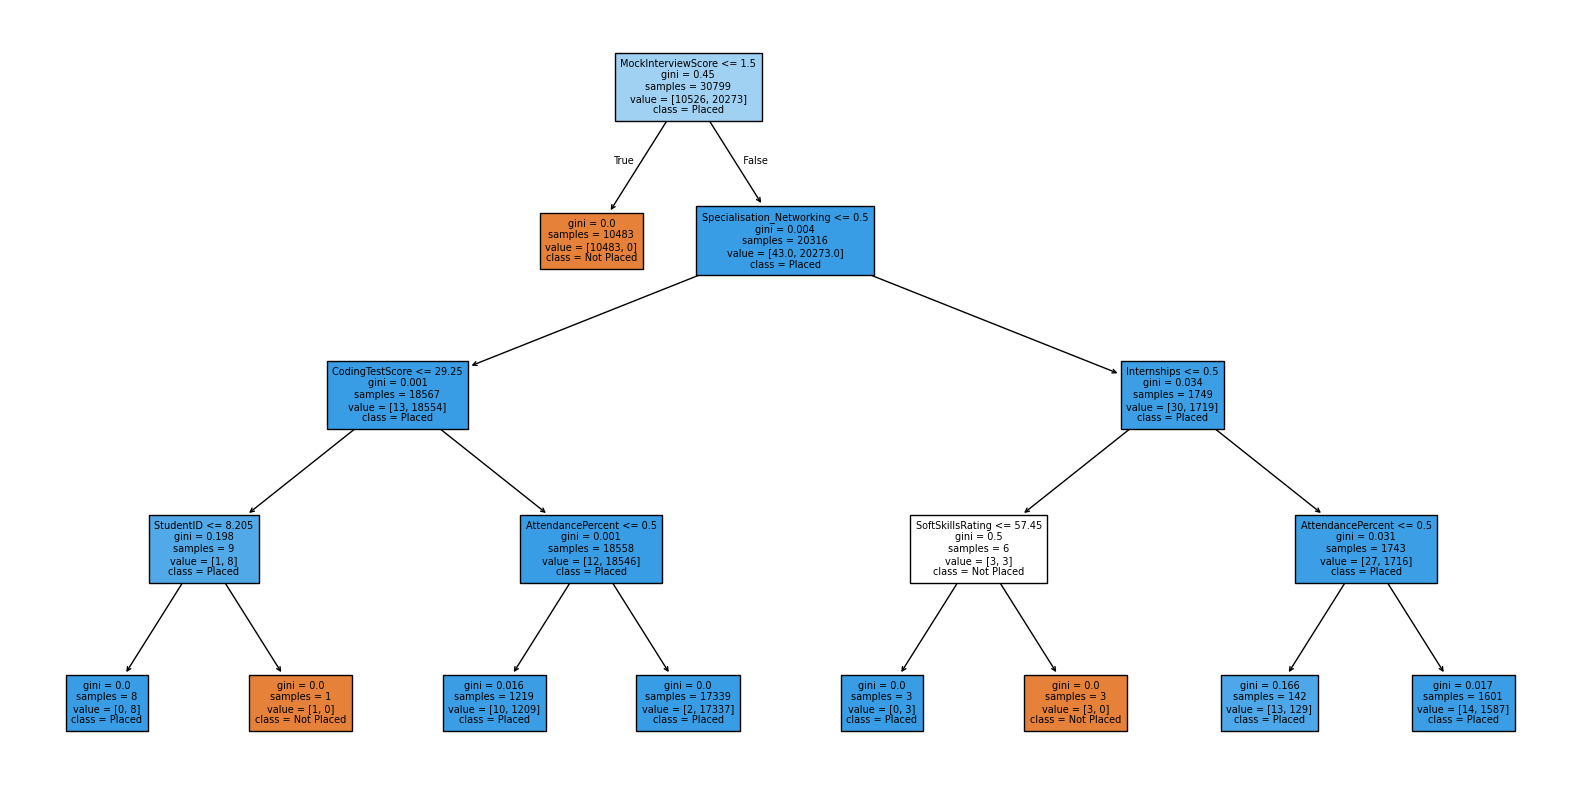

In [25]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    fontsize=7
)

plt.show()

In [26]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [28]:
df = pd.read_csv(file_path)

print(df.head())

   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...           0.0   
1               Yes       5.84       5.12  ...           0.0   
2                No       4.91       5.29  ...           0.0   
3                No       7.67       8.03  ...           0.0   
4                No       8.14       8.97  ...           1.0   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4                47.8   


In [30]:
X = df.drop(columns=["PlacementStatus", "StudentID"])
y = df["PlacementStatus"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

In [35]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns - crucial for consistent features between training and test sets
missing_cols_in_test = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for c in missing_cols_in_test:
    X_test_encoded[c] = 0

extra_cols_in_test = set(X_test_encoded.columns) - set(X_train_encoded.columns)
X_test_encoded = X_test_encoded.drop(columns=list(extra_cols_in_test))

X_test_encoded = X_test_encoded[X_train_encoded.columns]

# Handle NaN values in y_train before fitting
# Drop rows where y_train is NaN, and apply the same index drop to X_train_encoded
nan_in_y_train = y_train.isna()
if nan_in_y_train.any():
    print(f"Dropping {nan_in_y_train.sum()} rows from X_train_encoded and y_train due to NaN in y_train.")
    X_train_encoded = X_train_encoded[~nan_in_y_train]
    y_train = y_train[~nan_in_y_train]

rf.fit(X_train_encoded, y_train)

Dropping 1 rows from X_train_encoded and y_train due to NaN in y_train.


RandomForestClassifier(oob_score=True, random_state=42)

In [36]:
print("OOB Score:", rf.oob_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

OOB Score: 0.9986038054419119
Test Accuracy: 0.9985714285714286


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2664
         1.0       1.00      1.00      1.00      5036

    accuracy                           1.00      7700
   macro avg       1.00      1.00      1.00      7700
weighted avg       1.00      1.00      1.00      7700



In [38]:
print("Feature Importances:")

for name, importance in sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(name, ":", round(importance, 4))

Feature Importances:
Publications : 0.4134
SGPA_Sem1 : 0.0771
Specialisation : 0.0463
Internships : 0.0421
Stream : 0.0385
CollegeTier : 0.0367
HistoryOfBacklogs : 0.0363
Hostel : 0.0334
Projects : 0.0331
Gender : 0.0286
SGPA_Sem2 : 0.0277
AttendancePercent : 0.0275
City : 0.0244
SGPA_Sem5 : 0.0205
CGPA : 0.0157
SGPA_Sem7 : 0.0122
SGPA_Sem4 : 0.0095
SGPA_Sem6 : 0.0092
SGPA_Sem3 : 0.0053
SGPA_Sem8 : 0.0037
Workshops : 0.0005
Certifications : 0.0004
AptitudeTestScore : 0.0004
ExtraCurricular : 0.0003
SoftSkillsRating : 0.0003
MockInterviewScore : 0.0003
Salary Package : 0.0003
CodingTestScore : 0.0002
IsAnomaly : 0.0002
CGPA_Tier : 0.0002
